In [1]:
from typing import Annotated,TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages


##### TypedDict → state define karne ke liye
##### StateGraph → agent workflow banane ke liye
##### START / END → graph ka flow control
#####  add_messages → chat history handle karta hai

In [2]:
class State(TypedDict):
    message:Annotated[list,add_messages]

In [3]:
graph_builder=StateGraph(State)

### Create the Greet Node
A Node is a function-it does one task
Here,the nodes take the conversation(State("message))
then,it add the reply to the message history

In [4]:
def greet(state:State)->State:
    print("Greet state formait",state)
    state['message']=['Hello From Indian Ai production']
    return{'message':state['message']}

In [5]:
# greet({'messages': []})

#### ADD Node and Edges to the Graph

In [6]:
graph_builder.add_node('greet',greet)
graph_builder.add_edge(START,'greet')
graph_builder.add_edge('greet',END)

In [7]:
graph=graph_builder.compile()

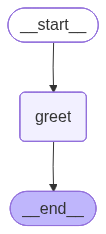

In [8]:
graph

In [9]:
graph.invoke({'messages':[]})

Greet state formait {'message': []}


{'message': [HumanMessage(content='Hello From Indian Ai production', additional_kwargs={}, response_metadata={}, id='3680a5b9-82d4-46c1-b4fe-e6510a750ac8')]}

In [13]:
graph.invoke({'messages':['Hi']})['message'][0].content

Greet state formait {'message': []}


'Hello From Indian Ai production'

## Create Chatbot 

In [ ]:
# from langchain.chat_models import init_chat_model
# from dotenv import load_dotenv
# load_dotenv(override=True)


True

In [ ]:
class State(TypedDict):
    message:Annotated[list,add_messages]

In [ ]:
graph_builder=StateGraph(State)

In [30]:
import os
from dotenv import load_dotenv
import google.generativeai as genai

from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage

# 🔐 Load .env
load_dotenv()

# 🔑 Get API Key
api_key = os.getenv("GOOGLE_API_KEY")

if not api_key:
    raise ValueError("API key not found in .env file ❌")

genai.configure(api_key=api_key)

# 🤖 Model
model = genai.GenerativeModel("gemini-2.5-flash")

# 🧠 State
class State(TypedDict):
    messages: Annotated[list, add_messages]

# 💬 Chatbot node
def chatbot(state: State) -> State:
    print("STATE:", state)

    messages = state.get("messages", [])

    # last user message
    user_input = messages[-1].content if messages else "Hello"

    response = model.generate_content(user_input)

    return {
        "messages": messages + [AIMessage(content=response.text)]
    }

# 🔗 Graph
graph_builder = StateGraph(State)

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

graph = graph_builder.compile()

# ▶️ Run
result = graph.invoke({
    "messages": [HumanMessage(content="Hi")]
})

print(result)

STATE: {'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='01c8125c-8a6a-49e6-8122-a4c6cbc40595')]}
{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='01c8125c-8a6a-49e6-8122-a4c6cbc40595'), AIMessage(content='Hi there! How can I help you today?', additional_kwargs={}, response_metadata={}, id='8da70c4e-d48a-4a7c-a2aa-aa9534b6e134', tool_calls=[], invalid_tool_calls=[])]}


In [31]:
print(result["messages"][-1].content)

Hi there! How can I help you today?


In [ ]:
from langchain_core.messages import HumanMessage




def chatbot_app(user_input: str, history):
    
    initial_state = {
        "messages": [HumanMessage(content=user_input)]
    }

    response = graph.invoke(initial_state)

    human_message = response["messages"][0].content
    ai_message = response["messages"][-1].content

    print("User:", human_message)
    print("AI:", ai_message)

    return ai_message

In [38]:
!pip install gradio

Defaulting to user installation because normal site-packages is not writeable
  Using cached gradio-6.10.0-py3-none-any.whl.metadata (17 kB)
  Using cached aiofiles-24.1.0-py3-none-any.whl.metadata (10 kB)
  Using cached audioop_lts-0.2.2-cp313-abi3-win_amd64.whl.metadata (2.0 kB)
  Using cached brotli-1.2.0-cp313-cp313-win_amd64.whl.metadata (6.3 kB)
  Using cached fastapi-0.135.2-py3-none-any.whl.metadata (28 kB)
  Using cached ffmpy-1.0.0-py3-none-any.whl.metadata (3.0 kB)
  Using cached gradio_client-2.4.0-py3-none-any.whl.metadata (7.1 kB)
  Using cached groovy-0.1.2-py3-none-any.whl.metadata (6.1 kB)
  Using cached hf_gradio-0.3.0-py3-none-any.whl.metadata (404 bytes)
  Using cached pydub-0.25.1-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached safehttpx-0.1.7-py3-none-any.whl.metadata (4.2 kB)
  Using cached semantic_version-2.10.0-py2.py3-none-any.whl.metadata (9.7 kB)
  Using cached starlette-0.52.1-py3-none-any.whl.metadata (6.3 kB)
  Using cached tomlkit-0.13.3-py3-none-


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Lenovo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
import gradio as gr
# 🚀 Gradio UI
chat_ui = gr.ChatInterface(
    fn=chatbot_app,
    title="🤖 My AI Agent (LangGraph + Gemini)",
    description="Ask anything!",
)

chat_ui.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


STATE: {'messages': [HumanMessage(content='hii', additional_kwargs={}, response_metadata={}, id='9779efa6-35dc-4a76-8515-4a8ee3b9617e')]}
User: hii
AI: Hi there! How can I help you today?
STATE: {'messages': [HumanMessage(content='my name is Harsh', additional_kwargs={}, response_metadata={}, id='ba2f75ac-f289-4df1-8edc-97aaf6796df4')]}
User: my name is Harsh
AI: Hello Harsh!
STATE: {'messages': [HumanMessage(content='who is the prime minster of india ', additional_kwargs={}, response_metadata={}, id='ad7f4ced-2f75-4330-9de1-13f160619481')]}
User: who is the prime minster of india 
AI: The current Prime Minister of India is **Narendra Modi**.

He has been in office since May 26, 2014, and is a member of the Bharatiya Janata Party (BJP). He recently began his third consecutive term as Prime Minister after the 2024 general election.
STATE: {'messages': [HumanMessage(content='what is my name ', additional_kwargs={}, response_metadata={}, id='cc906e04-dc96-4aff-8113-4be00841fee6')]}
User: 